**Dataset**: Poltava Governorate Population 19th Century  
**My analysis**: Jewish Population Density by District, Their Role in Society, and The Relationship With Other Groups  
**Context**: The Poltava governorate was part of the Pale of Settlement in the Russian Empire, where Jews were allowed to live. Only the western regions of the empire fell within this zone.  
**Goal**: Identifying settlement areas, finding the correlation with other segments of the population, revealing facts about co-existence with non-Jews

Anna Yastremska

In [16]:
import pandas as pd 
import geopandas as gpd
import matplotlib as plt
import numpy as np
import altair as alt
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

*Creating a Geojson for Maps* (ChatGPT)

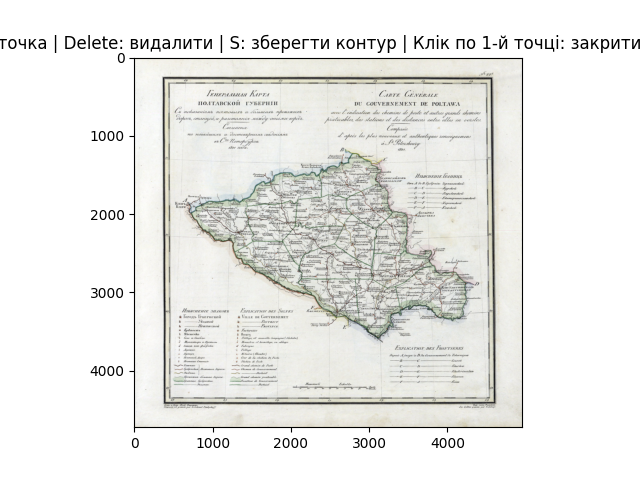

In [17]:
# інтерактивний режим для Jupyter
%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.backend_bases import MouseButton
from PIL import Image
import json
import os

# --- Налаштування ---
IMAGE_FILE = "Poltava_governorate_1821.jpg"  # твоя карта
OUTPUT_DIR = "geojson_outputs"
ALL_CONTOURS_FILE = os.path.join(OUTPUT_DIR, "all_contours.geojson")

# WGS84 bounding box карти (замінити на свої)
lon_min, lat_min = 30.0, 50.0
lon_max, lat_max = 31.0, 51.0

# --- Підготовка директорії ---
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Стан ---
points = []         # поточний контур (пікселі)
all_contours = []   # усі контури

# --- Функції ---
def pixel_to_wgs84(x, y, width, height):
    """Перетворення пікселя в WGS84."""
    lon = lon_min + (x / width) * (lon_max - lon_min)
    lat = lat_max - (y / height) * (lat_max - lat_min)
    return [lon, lat]

def save_all_contours():
    """Зберегти всі контури у GeoJSON."""
    width, height = img.size
    geojson = {"type": "FeatureCollection", "features": []}
    
    for contour in all_contours:
        wgs84_coords = [pixel_to_wgs84(px, py, width, height) for px, py in contour]
        wgs84_coords.append(pixel_to_wgs84(*contour[0], width, height))  # закриття
        feature = {
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [wgs84_coords]},
            "properties": {}
        }
        geojson["features"].append(feature)
    
    with open(ALL_CONTOURS_FILE, "w") as f:
        json.dump(geojson, f, indent=2)
    print(f"✔️ Збережено GeoJSON: {ALL_CONTOURS_FILE}")

def redraw():
    """Перемалювати всі контури та поточний контур."""
    ax.clear()
    ax.imshow(img)
    
    # Поточний contour
    if points:
        xs, ys = zip(*points)
        ax.plot(xs, ys, "-o", color="red", markersize=5)
    
    # Старі контури
    for contour in all_contours:
        xs, ys = zip(*(contour + [contour[0]]))
        ax.plot(xs, ys, "-", color="blue")
    
    fig.canvas.draw()

# --- Події ---
def on_click(event):
    global points, all_contours
    if event.inaxes is None:
        return
    x, y = event.xdata, event.ydata
    if x is None or y is None:
        return
    
    # Лівий клік = додати точку
    if event.button is MouseButton.LEFT:
        # замикання на першу точку
        if len(points) > 2:
            first_x, first_y = points[0]
            if abs(x - first_x) < 10 and abs(y - first_y) < 10:
                all_contours.append(points.copy())
                points = []
                redraw()
                save_all_contours()
                return
        
        points.append((x, y))
        redraw()

def on_key(event):
    global points, all_contours
    
    # Delete → прибрати останню точку
    if event.key == "delete" and points:
        points.pop()
        redraw()
    
    # S → зберегти contour
    elif event.key.lower() == "s" and points:
        print("💾 Збереження контуру…")
        all_contours.append(points.copy())
        points = []
        redraw()
        save_all_contours()

# --- Основне ---
img = Image.open(IMAGE_FILE)
fig, ax = plt.subplots()
ax.imshow(img)

fig.canvas.mpl_connect("button_press_event", on_click)
fig.canvas.mpl_connect("key_press_event", on_key)

plt.title("ЛКМ: точка | Delete: видалити | S: зберегти контур | Клік по 1-й точці: закрити контур")
plt.show()

**First Task** -- *identifying the location of Jewish communities*  
**Hypothesis**: there will be an extremely high concentration in certain districts - regional clusters

In [18]:
#creating a df with all districts in a row for future use
data_disctricts_in_rows = pd.read_csv("Народонаселення Полтавської губернії.xlsx - 7_Земля на ревізьку душу 1848.csv", header=1).fillna(0)
data_disctricts_in_rows = data_disctricts_in_rows.iloc[:-3,0]

data_disctricts_in_rows

0                Гадяцький
1             Зіньківський
2            Золотоніський
3              Кобеляцький
4     Констянтиноградський
5            Кременчуцький
6               Лохвицький
7               Лубенський
8            Миргородський
9            Переслявський
10             Полтавський
11              Прилуцький
12            Пирятинський
13              Роменський
14             Хорольський
Name: Повіт, dtype: object

In [19]:
#FOR 1835: district, number of Jews, total population

data_religion = pd.read_csv("Народонаселення Полтавської губернії.xlsx - 10_Міське населення.csv", header=2)

#choosing only columns with both genders included and necessary rows
data_religion = data_religion.iloc[0:-6,[0,6,9]]
#renaming confusing columns
data_religion = data_religion.rename(columns= {"о.с..1": "Євреї", "о.с..2": "Загальне населеня", "Місто": "Повіти"})

#replacing city names with the district it is located in
data_religion["Повіти"] = data_disctricts_in_rows

data_religion

,Повіти,Євреї,Загальне населеня
0,Гадяцький,973.0,4932.0
1,Зіньківський,261.0,7430.0
2,Золотоніський,1000.0,6031.0
3,Кобеляцький,320.0,8457.0
4,Констянтиноградський,296.0,1984.0
5,Кременчуцький,6855.0,18880.0
6,Лохвицький,989.0,7781.0
7,Лубенський,191.0,2694.0
8,Миргородський,306.0,7261.0
9,Переслявський,1522.0,8461.0


In [20]:
#FOR 1850: district, number of Jews, total population

data_religion2 = pd.read_csv("Народонаселення Полтавської губернії.xlsx - 10_Міське населення.csv", header=2)

#choosing only columns with both genders included and necessary rows
data_religion2 = data_religion2.iloc[0:-6,[0,15,18]]
#renaming confusing columns
data_religion2 = data_religion2.rename(columns= {"о.с..4": "Євреї", "о.с..5": "Загальне населеня", "Місто": "Повіти"})

#replacing city names with the district it is located in
data_religion2["Повіти"] = data_disctricts_in_rows

data_religion2

,Повіти,Євреї,Загальне населеня
0,Гадяцький,NaN,4909.0
1,Зіньківський,357.0,7715.0
2,Золотоніський,1198.0,5619.0
3,Кобеляцький,NaN,7752.0
4,Констянтиноградський,NaN,2289.0
5,Кременчуцький,6029.0,17074.0
6,Лохвицький,NaN,6460.0
7,Лубенський,407.0,2387.0
8,Миргородський,421.0,6418.0
9,Переслявський,2329.0,7907.0


In [21]:
#adding a year column for both dfs
data_religion["year"] = 1835
data_religion2["year"] = 1850

#correcting spelling differences
fixes = {
    "Констянтиноградський": "Костянтиноградський",
    "Переслявський": "Переяславський"
}
data_religion["Повіти"] = data_religion["Повіти"].replace(fixes)
data_religion2["Повіти"] = data_religion2["Повіти"].replace(fixes)

#calculating the fractions of Jews in the population
data_religion["Частка_Євреїв"] = data_religion["Євреї"] / data_religion["Загальне населеня"]
data_religion2["Частка_Євреїв"] = data_religion2["Євреї"] / data_religion2["Загальне населеня"]

#combining the two dfs
data_all = pd.concat([data_religion, data_religion2], ignore_index=True)

#loading geojson
gdf = gpd.read_file("final_geojson2.geojson")

#merging geojson with data on district names
gdf_merged = gdf.merge(data_all, left_on="name", right_on="Повіти", how="left")

#adding an interactive feature for the map -- year dropdown
year_dropdown = alt.binding_select(options=[1835, 1850], name="Year: ")
year_select = alt.selection_point(fields=["year"], bind=year_dropdown, value=1835)

#layer 1: stroke and white fill for NaN districts
base_layer = alt.Chart(gdf_merged).mark_geoshape(
    fill="white",
    stroke="#B8860B",
    strokeWidth=1.5
).encode(
    tooltip=[
        alt.Tooltip("name:N", title="District"),
        alt.Tooltip("year:O", title="Year"),
        alt.Tooltip("Частка_Євреїв:Q", title="% of Jews")

    ]
).transform_filter(
    year_select
)

#layer 2: color fill
data_layer = alt.Chart(gdf_merged).mark_geoshape(
    stroke="#F0B609",
    strokeWidth=1,
    strokeOpacity=0.3
).encode(
    color=alt.Color(
        "Частка_Євреїв:Q",
        scale=alt.Scale(range=["#FDF8E1", "#F9DC5C"]), #custom color range dependant on the fraction in disrtict
        legend=alt.Legend(title=None, format=".0%") 
    ),
    tooltip=[
        alt.Tooltip("name:N", title="District"),
        alt.Tooltip("year:O", title="Year"),
        alt.Tooltip("Частка_Євреїв:Q", title="% of Jews", format=".1%")
    ]
).transform_filter(
    year_select
).transform_filter(
    "datum.Частка_Євреїв != null"
)

#combining two layers
map_chart = (base_layer + data_layer).add_params(
    year_select
).properties(
    width=600,
    height=500,
    title="% of Jews in the Poltava region"
).project(
    type="identity",
    reflectY=True
)

map_chart

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


In [22]:
#selecting the fraction for the bar chart
bar_data = gdf_merged[gdf_merged["Частка_Євреїв"].notna()].copy()

#creating a selection that highlights on hover
highlight = alt.selection_point(
    on="mouseover",
    fields=["name", "year"],
    nearest=True,
    empty=False
)

#create a selection for clicking to filter by year
click_select = alt.selection_point(
    fields=["year"],
    empty=True
)

grouped_bars = alt.Chart(bar_data).mark_bar().encode(
    x=alt.X("name:N", 
            title="District",
            axis=alt.Axis(labelAngle=-45)), #name of district on the x-axis
    y=alt.Y("Частка_Євреїв:Q", 
            title="% of Jews",
            axis=alt.Axis(format=".0%")), #fraction in districts on the y-axis
    color=alt.condition(
        click_select,
        alt.Color("year:O",
                  scale=alt.Scale(range=["#F9DC5C", "#F0B609"]),
                  legend=alt.Legend(title="Year")), #adding legend for the correspondance: color -> year
        alt.value("lightgray")
    ),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.7)),
    xOffset="year:O",
    tooltip=[
        alt.Tooltip("name:N", title="District"),
        alt.Tooltip("year:O", title="Year"),
        alt.Tooltip("Частка_Євреїв:Q", title="% of Jews", format=".1%")
    ]
).add_params(
    highlight,
    click_select
).properties(
    width=600,
    height=400,
    title="% of Jews per District"
)

grouped_bars

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


**CONCLUSION 1**: Кременчуцький district appears to be the main regional center for Jews. Additionally, Переяславський district, had a major rise in Jewish population since 1835, as well as Любенський and Роменський.

**Second Task** -- *is there a correlation between the number of townspeople, merchants, and Jews?*  
**Hypothesis**: Historically, Jews concentrated in cities and towns where the merchant class was dominant.

In [23]:
data_1848 = pd.read_csv("Народонаселення Полтавської губернії.xlsx - 2_Народонаселення на 1848 р..csv",
             header=None).fillna(0)

#names of huberniyas are in the first row
huberniya = data_1848.iloc[0]

#shifting huberniya names to the right so that they align with о.п columns 
shifted_huberniya = huberniya.shift(2)

#replacing the first row with the shifted one
data_1848.iloc[0] = shifted_huberniya

#due to shifts, the headers turn into numbers, so:
data_1848.columns = data_1848.iloc[0] #huberniya names for column names
data_1848.columns.values[0] = "Сословия жителей"  # make first column unique (error fix idk why)

list_jews_city_merchants = [ 
    "Евреев",
    "Мещан всех разрядов",
    "Мещан",
    "Купцов",
    "Купечества всех разрядов"
] #the needed rows in a list

first_col = "Сословия жителей"

full_jews_city_merchants = data_1848[data_1848[first_col].isin(list_jews_city_merchants)]
#choosing all columns where the first row contains an element from our list

jews_city_merchants = full_jews_city_merchants.iloc[:, ::3].drop(columns="Вся губернія") 
#keeping only о.п columns (both men and women)
jews_city_merchants

#adding index for aggregation
jews_city_merchants.set_index("Сословия жителей", inplace=True)
# Make sure all columns are numeric
jews_city_merchants = jews_city_merchants.apply(pd.to_numeric, errors='coerce')

#aggregating rows
jews_city_merchants.loc["Купці"] = (jews_city_merchants.loc["Купечества всех разрядов"] + jews_city_merchants.loc["Купцов"])
jews_city_merchants.loc["Міщани"] = (jews_city_merchants.loc["Мещан всех разрядов"] + jews_city_merchants.loc["Мещан"])
jews_city_merchants.loc["Євреї"] = jews_city_merchants.loc["Евреев"]

jews_city_merchants = jews_city_merchants.iloc[5:8]

jews_city_merchants

,Гадяцький,Зіньківський,Золотоніський,Кобеляцький,Костянтиноградський,Кременчуцький,Лохвицький,Лубенський,Миргородський,Переяславський,Полтавський,Прилуцький,Пирятинський,Роменський,Хорольський
Сословия жителей,,,,,,,,,,,,,,,
Купці,169,149,130,139,66,925,44,102,53,249,463,118,89,376,132
Міщани,2464,2263,2412,778,829,9081,110,1153,1038,554,8345,4670,1073,2361,1638
Євреї,973,261,1000,310,296,6855,989,191,306,1522,2049,1153,419,764,0


In [24]:
#transforming the index back into a column
jews_city_merchants = jews_city_merchants.reset_index()


#creating new dfs for each category (same process for all)
merchants = (
    jews_city_merchants[jews_city_merchants[first_col] == "Купці"]
    .iloc[:, 1:] #dropping the name column
    .sum() #converting to Series
)
merchants_df = pd.DataFrame({
    "district": merchants.index, #district names become a column
    "Купці": merchants.values #values become a column
})

townspeople = (
    jews_city_merchants[jews_city_merchants[first_col] == "Міщани"]
    .iloc[:, 1:] 
    .sum()
)
townspeople_df = pd.DataFrame({
    "district": townspeople.index,
    "Міщани": townspeople.values
})

jews = (
    jews_city_merchants[jews_city_merchants[first_col] == "Євреї"]
    .iloc[:, 1:]
    .sum()
)
jews_df = pd.DataFrame({
    "district": jews.index,
    "Євреї": jews.values
})

#removing whitespaces
for df in [merchants_df, townspeople_df, jews_df]:
    df["district"] = df["district"].str.strip()

#loading geojson
gdf = gpd.read_file("final_geojson2.geojson")

#merging with geojson on names/districts
gdf_merchants = gdf.merge(merchants_df, left_on="name", right_on="district", how="left")
gdf_townspeople = gdf.merge(townspeople_df, left_on="name", right_on="district", how="left")
gdf_jews = gdf.merge(jews_df, left_on="name", right_on="district", how="left")

#merchants map
map_merchants = alt.Chart(gdf_merchants).mark_geoshape(
    stroke="white",
    strokeWidth=1
).encode(
    color=alt.Color("Купці:Q", 
                    scale=alt.Scale(scheme="blues", type="log"), #blue scale dependant on number (value) of merchants per district
                    title=None),
    tooltip=[alt.Tooltip("name:N", title="District"), 
             alt.Tooltip("Купці:Q", title="Merchants")]
).properties(
    width=300,
    height=400,
    title="Merchants"
).project(type="identity", reflectY=True)

#townspeople map
map_townspeople = alt.Chart(gdf_townspeople).mark_geoshape(
    stroke="white",
    strokeWidth=1
).encode(
    color=alt.Color("Міщани:Q",
                    scale=alt.Scale(scheme="greens", type="quantile"), #green scale dependant on number (value) of townspeople per district
                    title=None),
    tooltip=[alt.Tooltip("name:N", title="District"), 
             alt.Tooltip("Міщани:Q", title="Townspeople")]
).properties(
    width=300,
    height=400,
    title="Townspeople"
).project(type="identity", reflectY=True)

#Jews map
map_jews = alt.Chart(gdf_jews).mark_geoshape(
    stroke="white",
    strokeWidth=1
).encode(
    color=alt.Color("Євреї:Q",
                    scale=alt.Scale(scheme="oranges", type="quantile"), #orange scale dependant on number (value) of Jews per district
                    title=None),
    tooltip=[alt.Tooltip("name:N", title="District"), 
             alt.Tooltip("Євреї:Q", title="Jews")]
).properties(
    width=300,
    height=400,
    title="Jews"
).project(type="identity", reflectY=True)

#i used different scale types (log/quantile) so that the maps are displayed in the set colors

#displaying all maps together (concatinating)
alt.hconcat(map_merchants, map_jews, map_townspeople)

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


*Now I will take a look at the actual correlation.*  

Positive correlation: > 0  
Negative correlation: < 0  

Statistically significant IF p < 0.05


In [25]:
#looking for population density for future use
data_population_per_district = pd.read_csv("Народонаселення Полтавської губернії.xlsx - 5_Жителі і двори в повітах 1848.csv", header=0).fillna(0)

#removing unnecessary rows
data_population_per_district = data_population_per_district[:-3]

#keeping only district name and population density
data_population_per_district = data_population_per_district.iloc[:,[0,3]]

data_population_per_district

,Повіт,Населеність
0,Гадяцький,7.585837
1,Зіньківський,7.592447
2,Золотоніський,8.532141
3,Кобеляцький,8.981530
4,Констянтиноградський,7.927277
5,Кременчуцький,9.413660
6,Лохвицький,8.220950
7,Лубенський,8.871316
8,Миргородський,6.859782
9,Переслявський,9.591597


In [26]:
#calculating the correlation between the number of Jews and merchants + removing outliers
from scipy import stats

#merge merchants, jews, and population density
correlation_data_merchants = merchants_df.merge(jews_df, on="district", how="inner")\
                               .merge(data_population_per_district.rename(columns={"Повіт":"district", "Населеність":"population_density"}), on="district", how="left")

#converting to numeric
correlation_data_merchants["Купці"] = pd.to_numeric(correlation_data_merchants["Купці"], errors="coerce")
correlation_data_merchants["Євреї"] = pd.to_numeric(correlation_data_merchants["Євреї"], errors="coerce")
correlation_data_merchants["population_density"] = pd.to_numeric(correlation_data_merchants["population_density"], errors="coerce")

#removing missing values
correlation_data_merchants = correlation_data_merchants.dropna(subset=["Купці", "Євреї", "population_density"])
correlation_data_merchants = correlation_data_merchants[correlation_data_merchants["district"] != ""]
correlation_data_merchants = correlation_data_merchants.reset_index(drop=True)

#printing the initial number of districts
print("MERCHANTS CORRELATION")

#calculating the Pearson correlation
pearson_corr_merchants_orig, pearson_p_merchants_orig = stats.pearsonr(
    correlation_data_merchants["Купці"],
    correlation_data_merchants["Євреї"]
)

print(f"Pearson correlation (with outliers): {pearson_corr_merchants_orig:.3f} (p-value: {pearson_p_merchants_orig:.4f})")

#removing outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if len(outliers) > 0:
        print(f"\n{column} outliers removed:")
        print(outliers[["district", column]])
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

#removing outliers using the function
correlation_data_merchants_clean = remove_outliers_iqr(correlation_data_merchants, "Купці")
correlation_data_merchants_clean = remove_outliers_iqr(correlation_data_merchants_clean, "Євреї")

#calculating the new correlation
pearson_corr_merchants_clean, pearson_p_merchants_clean = stats.pearsonr(
    correlation_data_merchants_clean["Купці"],
    correlation_data_merchants_clean["Євреї"]
)

print(f"Pearson correlation (without outliers): {pearson_corr_merchants_clean:.3f} (p-value: {pearson_p_merchants_clean:.4f})")


#calculating the correlation between the number of Jews and townspeople + removing outliers

#merge townspeople, jews, and population density
correlation_data_townspeople = townspeople_df.merge(jews_df, on="district", how="inner")\
                               .merge(data_population_per_district.rename(columns={"Повіт":"district", "Населеність":"population_density"}), on="district", how="left")

#converting to numeric
correlation_data_townspeople["Міщани"] = pd.to_numeric(correlation_data_townspeople["Міщани"], errors="coerce")
correlation_data_townspeople["Євреї"] = pd.to_numeric(correlation_data_townspeople["Євреї"], errors="coerce")
correlation_data_townspeople["population_density"] = pd.to_numeric(correlation_data_townspeople["population_density"], errors="coerce")

#removing missing values
correlation_data_townspeople = correlation_data_townspeople.dropna(subset=["Міщани", "Євреї", "population_density"])
correlation_data_townspeople = correlation_data_townspeople[correlation_data_townspeople["district"] != ""]
correlation_data_townspeople = correlation_data_townspeople.reset_index(drop=True)

#printing the initial number of districts
print("TOWNSPEOPLE CORRELATION")

#calculating the Pearson correlation
pearson_corr_townspeople_orig, pearson_p_townspeople_orig = stats.pearsonr(
    correlation_data_townspeople["Міщани"],
    correlation_data_townspeople["Євреї"]
)

print(f"Pearson correlation (with outliers): {pearson_corr_townspeople_orig:.3f} (p-value: {pearson_p_townspeople_orig:.4f})")

#removing outliers using the function
correlation_data_townspeople_clean = remove_outliers_iqr(correlation_data_townspeople, "Міщани")
correlation_data_townspeople_clean = remove_outliers_iqr(correlation_data_townspeople_clean, "Євреї")

#calculating the new correlation
pearson_corr_townspeople_clean, pearson_p_townspeople_clean = stats.pearsonr(
    correlation_data_townspeople_clean["Міщани"],
    correlation_data_townspeople_clean["Євреї"]
)

print(f"Pearson correlation (without outliers): {pearson_corr_townspeople_clean:.3f} (p-value: {pearson_p_townspeople_clean:.4f})")

MERCHANTS CORRELATION
Pearson correlation (with outliers): 0.919 (p-value: 0.0000)

Купці outliers removed:
         district  Купці
4   Кременчуцький    925
8     Полтавський    463
11     Роменський    376
Pearson correlation (without outliers): -0.008 (p-value: 0.9822)
TOWNSPEOPLE CORRELATION
Pearson correlation (with outliers): 0.812 (p-value: 0.0007)

Міщани outliers removed:
        district  Міщани
4  Кременчуцький    9081
8    Полтавський    8345
9     Прилуцький    4670
Pearson correlation (without outliers): 0.206 (p-value: 0.5673)


For townspeople: *The correlation decreases as outliers are removed.*  
For merchants: *The correlation appears **extremely** strong, yet once the outliers are removed -- it vanishes completely* 

*Let's take a closer look at the correlation with merchants...*

In [27]:
#creating two scatter plots representing the correlation -- with and without the outliers

#creating hover selection
hover = alt.selection_point(
    fields=["district"],
    on="mouseover",
    nearest=True,
    empty=False
)

#chart 1 (with outliers)
base_orig = alt.Chart(correlation_data_merchants).encode(
    x=alt.X("Купці:Q", 
            title="Merchants", #number of merchants on the x-axis
            axis=alt.Axis(grid=False)),
    y=alt.Y("Євреї:Q", 
            title="Jews", #number of Jews on the y-axis
            axis=alt.Axis(grid=True),
            scale=alt.Scale(domain=[0, 7000]))  #setting y-axis domain (had negative start by default)
)

scatter_orig = base_orig.mark_circle(opacity=0.7, stroke="black", strokeWidth=0).encode(
    size=alt.Size("population_density:Q", 
                  title="Population Density",
                  scale=alt.Scale(domain=[
                      correlation_data_merchants["population_density"].min(),
                      correlation_data_merchants["population_density"].max() #setting the circle scale domain
                  ], range=[200, 2000]),
                  legend=alt.Legend(
                      symbolLimit=3, #limiting the legend so that it doesn't take too much space
                      values=[
                          correlation_data_merchants["population_density"].min(),
                          correlation_data_merchants["population_density"].median(),
                          correlation_data_merchants["population_density"].max() #size of examples in the legend
                      ],
                      labelExpr="''",
                      orient="right", #legend placement
                      direction="vertical"
                  )),
    color=alt.Color("district:N", 
                    title="District",
                    scale=alt.Scale(scheme="category20"), 
                    legend=alt.Legend(
                        orient="right",
                        columns=1
                    )),
    strokeWidth=alt.condition(hover, alt.value(1), alt.value(0)), #stroke width changes when you hover
    tooltip=[
        alt.Tooltip("district:N", title="District"),
        alt.Tooltip("Купці:Q", title="Merchants"),
        alt.Tooltip("Євреї:Q", title="Jews"),
        alt.Tooltip("population_density:Q", title="Density", format=".2f")
    ]
).add_params(
    hover
)

#adding district labels on hover for original chart
text_orig = base_orig.mark_text(
    align="left",
    dx=7,
    dy=-25, #shifting the text until it's perfectly visible
    fontSize=11,
    fontWeight="bold"
).encode(
    text="district:N",
    opacity=alt.condition(hover, alt.value(0.8), alt.value(0)) #text disappears when you don't hover
).transform_filter(
    hover
)

#trend line 1
trend_orig = base_orig.mark_line(color="red", strokeDash=[5, 5], size=3).transform_regression(
    "Купці", "Євреї"
)

#combining chart features
chart_orig = (scatter_orig + text_orig + trend_orig).properties(
    width=400,
    height=400,
    title={
        "text": "With outliers",
        "subtitle": f"r = {pearson_corr_merchants_orig:.3f} (p = {pearson_p_merchants_orig:.4f}) | n = {len(correlation_data_merchants)}"
    }
)

#chart 2 (without outliers)
base_clean = alt.Chart(correlation_data_merchants_clean).encode(
    x=alt.X("Купці:Q", 
            title=None,
            axis=alt.Axis(grid=False)), #number of merchants on the x-axis
    y=alt.Y("Євреї:Q", 
            title=None,
            axis=alt.Axis(grid=True)) #number of Jews on the y-axis
)

scatter_clean = base_clean.mark_circle(opacity=0.7, stroke="black", strokeWidth=0).encode(
    size=alt.Size("population_density:Q", 
                  title="Population Density",
                  scale=alt.Scale(domain=[
                      correlation_data_merchants_clean["population_density"].min(),
                      correlation_data_merchants_clean["population_density"].max() #setting the circle scale domain
                  ], range=[200, 2000])),
    color=alt.Color("district:N", 
                    title="District",
                    scale=alt.Scale(scheme="category20")), #same colors
    strokeWidth=alt.condition(hover, alt.value(1), alt.value(0)), #stroke changes when you hover
    tooltip=[
        alt.Tooltip("district:N", title="District"),
        alt.Tooltip("Купці:Q", title="Merchants"),
        alt.Tooltip("Євреї:Q", title="Jews"),
        alt.Tooltip("population_density:Q", title="Density", format=".2f")
    ]
).add_params(
    hover
)

#district labels on hover for clean chart
text_clean = base_clean.mark_text(
    align="left",
    dx=7,
    dy=-25, #shifting the text until it's perfectly visible
    fontSize=11,
    fontWeight="bold"
).encode(
    text="district:N",
    opacity=alt.condition(hover, alt.value(0.8), alt.value(0)) #text disappears when you don't hover
).transform_filter(
    hover
)

#trend line 2
trend_clean = base_clean.mark_line(color="red", strokeDash=[5, 5], size=3).transform_regression(
    "Купці", "Євреї"
)

#combining features of the 2nd chart
chart_clean = (scatter_clean + text_clean + trend_clean).properties(
    width=400,
    height=400,
    title={
        "text": "Without outliers",
        "subtitle": f"r = {pearson_corr_merchants_clean:.3f} (p = {pearson_p_merchants_clean:.4f}) | n = {len(correlation_data_merchants_clean)}"
    }
)

#placing the 2 charts side by side
combined_chart = (chart_orig | chart_clean).properties(
    title={
        "text": "Correlation Between Jews and Merchants",
        "fontSize": 16,
        "anchor": "middle"
    }
).configure_concat(
    spacing=100
).configure(
    padding={"left": 20, "top": 20, "right": 100, "bottom": 20}, #adjusting appearence
    view={"strokeWidth": 0},
)

display(combined_chart)

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


**CONCLUSION 2**: The correlstion exists only in big commerical centers of the region. In more rural districts the number of Jews is unrelated to the number of merchants. As for townspeople, there is in fact a positive correlation. However, it is not statistically significant.

**Task Three** -- *proving whether more Cossacks -> less Jews*  
**Hypothesis**: The Cossack regions were predominantly agrarian + had frequent conflicts with Jews.

In [28]:
data_1850 = pd.read_csv("Народонаселення Полтавської губернії.xlsx - 1_Народонаселення на 1850 р..csv",
             header=None)

#names of huberniyas are in the first row
huberniya2 = data_1850.iloc[0]

#shifting huberniya names to the right so that they align with о.п columns 
shifted_huberniya2 = huberniya2.shift(2)

#replacing the first row with the shifted one
data_1850.iloc[0] = shifted_huberniya2

#due to shifts, the headers turn into numbers, so:
data_1850.columns = data_1850.iloc[0] #huberniya names for column names
data_1850.columns.values[0] = "Сословия жителей"  # make first column unique (error fix idk why)

list_cossacks = [
    "Малороссийских козаков",
    "Малороссийских козаков на льготе"
] #the needed rows in a list

#choosing all columns where the first row contains an element from our list
full_cossacks = data_1850[data_1850[first_col].isin(list_cossacks)]

#keeping only о.п columns (both men and women)

cossacks = full_cossacks.iloc[:, ::3].drop(columns="Губернія загалом").reset_index(drop=True)

#swapping rows and columns
jews_df_trans = jews_df.transpose()

#setting the first row as the header (district names)
jews_df_trans.columns = jews_df_trans.iloc[0]
jews_df_trans = jews_df_trans[1:]

#adding the same first column as in cossacks
jews_df_trans.insert(0, "Сословия жителей", "Євреї")

#removing white spaces
cossacks.columns = cossacks.columns.str.strip()
jews_df_trans.columns = jews_df_trans.columns.str.strip()

#reindexing to match cossacks columns
jews_df_trans = jews_df_trans[cossacks.columns]

#create one df
cossacks_jews = pd.concat([cossacks, jews_df_trans])
cossacks_jews.set_index("Сословия жителей", inplace=True)

#converting to numeric before aggregation
cossacks_jews = cossacks_jews.apply(pd.to_numeric, errors="coerce")

#creating a separate cossacks row
cossacks_jews.loc["Козаки"] = (cossacks_jews.loc["Малороссийских козаков"] + cossacks_jews.loc["Малороссийских козаков на льготе"])
cossacks_jews = cossacks_jews.iloc[2:4]


cossacks_jews

,Гадяцький,Зіньківський,Золотоніський,Кобеляцький,Костянтиноградський,Кременчуцький,Лохвицький,Лубенський,Миргородський,Переяславський,Полтавський,Прилуцький,Пирятинський,Роменський,Хорольський
Сословия жителей,,,,,,,,,,,,,,,
Євреї,973,261,1000,310,296,6855,989,191,306,1522,2049,1153,419,764,0
Козаки,31779,62829,64483,66281,5907,57021,56989,41903,57656,51415,5689,36084,21337,62374,44916


In [29]:
from scipy import stats

#swapping rows and columns
correlation_data = cossacks_jews.T.reset_index()
correlation_data.columns = ["district", "Jews", "Cossacks"]

#converting to numeric
correlation_data["Cossacks"] = pd.to_numeric(correlation_data["Cossacks"], errors="coerce")
correlation_data["Jews"] = pd.to_numeric(correlation_data["Jews"], errors="coerce")

#removing missing values
correlation_data = correlation_data.dropna(subset=["Cossacks", "Jews"])
correlation_data = correlation_data[correlation_data["district"] != ""]

#removing districts with missing values
correlation_data = correlation_data[(correlation_data["Cossacks"] > 0) & (correlation_data["Jews"] > 0)]
correlation_data = correlation_data.reset_index(drop=True)

#removing outliers
correlation_data_clean = remove_outliers_iqr(correlation_data, "Cossacks")
correlation_data_clean = remove_outliers_iqr(correlation_data_clean, "Jews")

print(f"\nAfter outlier removal: {len(correlation_data_clean)} districts")
print(f"Removed: {len(correlation_data) - len(correlation_data_clean)} outliers")

#calculating Pearson correlation
pearson_corr_clean, pearson_p_clean = stats.pearsonr(
    correlation_data_clean["Cossacks"],
    correlation_data_clean["Jews"]
)

print(f"Pearson correlation: {pearson_corr_clean:.3f} (p-value: {pearson_p_clean:.4f})")

#creating selection on hover
hover = alt.selection_point(
    fields=["district"],
    on="mouseover",
    nearest=True,
    empty=False
)

#sorting by cossacks descending
df = correlation_data_clean.sort_values("Cossacks", ascending=False).reset_index(drop=True)

#altering the df to create a heatmap (one row for jews, one row for cossacks)
df_long = df.melt(
    id_vars=["district"], 
    value_vars=["Cossacks", "Jews"],
    var_name="group",
    value_name="population"
)

#calculating medians for text color
median_cossacks = df["Cossacks"].median()
median_jews = df["Jews"].median()

#cossacks heatmap
heatmap_cossacks = alt.Chart(df_long[df_long["group"] == "Cossacks"]).mark_rect(
    cornerRadius=3
).encode(
    x=alt.X("group:N", 
            axis=alt.Axis(labelFontSize=15, labelFontWeight="bold", labelPadding=10, labelAngle=0, title=None), #Cossacks column
            scale=alt.Scale(paddingInner=0)), 
    y=alt.Y("district:N", 
            sort=df["district"].tolist(), #districts as cells
            title="", 
            axis=alt.Axis(labelFontSize=12, labelLimit=250)),
    color=alt.Color("population:Q", 
                    scale=alt.Scale(scheme="purples", domain=[df["Cossacks"].min(), df["Cossacks"].max()]),
                    legend=None),
    strokeWidth=alt.condition(hover, alt.value(3), alt.value(0.5)),
    stroke=alt.condition(hover, alt.value("#1f1f1f"), alt.value("#f0f0f0")),
    tooltip=[
        alt.Tooltip("district:N", title="District"),
        alt.Tooltip("population:Q", title="Cossacks", format=",")
    ]
).add_params(hover).properties(width=160, height=580)

#Jews heatmap
heatmap_jews = alt.Chart(df_long[df_long["group"] == "Jews"]).mark_rect(
    cornerRadius=3
).encode(
    x=alt.X("group:N", 
            axis=alt.Axis(labelFontSize=15, labelFontWeight="bold", labelPadding=10, labelAngle= 0, title=None), #Jews column
            scale=alt.Scale(paddingInner=0)),
    y=alt.Y("district:N", 
            sort=df["district"].tolist(), #districts as cells
            title=None, 
            axis=alt.Axis(labels=False)),
    color=alt.Color("population:Q", 
                    scale=alt.Scale(scheme="purples", type="quantile"),
                    legend=alt.Legend(
                        title=None,
                        labelExpr="",
                        orient="right",
                        direction="vertical",
                        gradientLength=200,
                        gradientThickness=15
                    )),
    strokeWidth=alt.condition(hover, alt.value(3), alt.value(0.5)),
    stroke=alt.condition(hover, alt.value("#1f1f1f"), alt.value("#f0f0f0")),
    tooltip=[
        alt.Tooltip("district:N", title="District"),
        alt.Tooltip("population:Q", title="Jews", format=",")
    ]
).add_params(hover).properties(width=160, height=580)

#creating text layers

text_cossacks = alt.Chart(df_long[df_long["group"] == "Cossacks"]).mark_text(
    baseline="middle", 
    fontSize=10,
    fontWeight="bold"
).encode(
    x=alt.X("group:N", scale=alt.Scale(paddingInner=0)),
    y=alt.Y("district:N", sort=df["district"].tolist()),
    text=alt.Text("population:Q", format=",.0f"),
    color=alt.condition(
        f"datum.population > {median_cossacks}",
        alt.value("white"),
        alt.value("#2d2d2d")
    )
)

text_jews = alt.Chart(df_long[df_long["group"] == "Jews"]).mark_text(
    baseline="middle", 
    fontSize=10,
    fontWeight="bold"
).encode(
    x=alt.X("group:N", scale=alt.Scale(paddingInner=0)),
    y=alt.Y("district:N", sort=df["district"].tolist()),
    text=alt.Text("population:Q", format=",.0f"),
    color=alt.condition(
        f"datum.population > {median_jews}",
        alt.value("white"),
        alt.value("#2d2d2d")
    )
)

#combining charts
chart = (heatmap_cossacks + text_cossacks | heatmap_jews + text_jews).properties(
    title={
        "text": "Negative Correlation: Cossacks and Jews",
        "subtitle": [
            "Poltava Governorate, 1850",
            f"Pearson r = {pearson_corr_clean:.3f} • p-value = {pearson_p_clean:.3f} • n = {len(correlation_data_clean)}"
        ],
        "fontSize": 18,
        "fontWeight": "bold",
        "subtitleFontSize": 12,
        "subtitleColor": "#666",
        "anchor": "start",
        "offset": 20
    }
).configure_view(
    strokeWidth=0
).configure_axis(
    labelLimit=250,
    domainColor="#ddd",
    tickColor="#ddd"
).configure_concat(
    spacing=0
)

chart


Jews outliers removed:
        district  Jews
5  Кременчуцький  6855

After outlier removal: 13 districts
Removed: 1 outliers
Pearson correlation: -0.273 (p-value: 0.3672)


<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


**Conclusion 3**: The correlation between the number of Cossacks and Jews is non-existent. The hypothesis was proved to be false.

**RESULTS**:  
**1. Кременчуцький district emerged as the dominant Jewish center, with the highest concentration throughout the period.**  
*Interpretation*: The growth of the Jewish population in the city is linked to the economic growth of Kremenchuk: Jews from small towns moved here in search of work, as it was a major trading hub.  
**2. Merchants showed a strong correlation with Jewish population, but only in major commercial centers, not rural districts. While the initial correlation with townspeople collapsed after outliers got removed, showing Jewish economic activity was highly concentrated in specific urban cities.**  
*Interpretation*: Imperial restrictions barred Jews from agriculture by not allowing them to own land. Consequently, they turned to trade and crafts. The data confirms Jews succeeded in permitted commercial activities within authorized urban settlements, while remaining absent from rural economies.  
**3. No correlation between Cossack and Jewish populations may indicate spatial separation.**  
*Interpretation*: Jews concentrated in commercial towns while Cossacks remained in military settlements and agricultural areas. This also reflects the legacy of 17th-century violence that established patterns of mutual avoidance.